In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data   # (150, 4)
n = len(x)


In [15]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))


In [18]:
wcss_values = []

for K in range(1, 11):
    print("\n==============================")
    print("Running for K =", K)
    print("==============================")
    
    # Initial centroids
    centroids = x[:K].copy()
    print("Initial Centroids:\n", centroids)
    
    for iteration in range(10):
        print("\nIteration:", iteration + 1)
        
        distances = []
        
        # Step 1: Calculate distances
        for k in range(K):
            dist_k = []
            for i in range(n):
                dist = euclidean_distance(x[i], centroids[k])
                dist_k.append(dist)
            distances.append(dist_k)
        
        distances = np.array(distances)
        print("Distance matrix shape:", distances.shape)   # (K, n)
        
        # Step 2: Assign labels
        labels = []
        for i in range(n):
            point_distances = distances[:, i]
            label = np.argmin(point_distances)
            labels.append(label)
        
        labels = np.array(labels)
        print("Labels (first 20):", labels[:20])
        
        # Step 3: Update centroids
        new_centroids = []
        
        for k in range(K):
            cluster_points = x[np.where(labels == k)[0]]
            print(f"Cluster {k} size:", len(cluster_points))
            
            if len(cluster_points) > 0:
                new_centroid = np.mean(cluster_points, axis=0)
            else:
                new_centroid = centroids[k]
            
            new_centroids.append(new_centroid)
        
        new_centroids = np.array(new_centroids)
        print("Updated Centroids:\n", new_centroids)
        
        # Step 4: Check convergence
        if np.all(centroids == new_centroids):
            print("Converged at iteration", iteration + 1)
            break
        
        centroids = new_centroids
    
    # Step 5: Calculate WCSS
    wcss = 0
    for k in range(K):
        cluster_points = x[np.where(labels == k)[0]]
        for point in cluster_points:
            wcss += euclidean_distance(point, centroids[k])**2
    
    print("Final WCSS for K =", K, ":", wcss)
    wcss_values.append(wcss)

print("\n==============================")
print("All WCSS values:")
print(wcss_values)


K = 1
K = 2
K = 3
K = 4
K = 5
K = 6
K = 7
K = 8
K = 9
K = 10


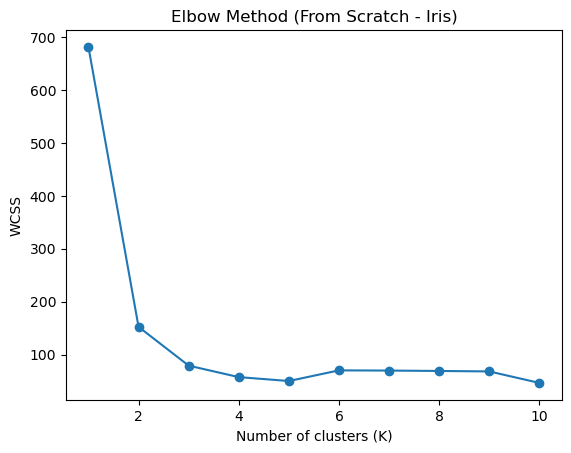

In [17]:
plt.plot(range(1, 11), wcss_values, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method (From Scratch - Iris)")
plt.show()
